# N1 — Introdução a LangGraph

* Professor: Júlio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Alejandro Núñez Arroyo <a href="mailto:r299215@dac.unicamp.br">(r299215@dac.unicamp.br)</a>
* Material base: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>

Este notebook introduz o LangGraph a partir de exemplos executáveis, sem chamadas a LLM. O foco está no modelo de grafos de execução: estado, nós, arestas, atualização parcial, roteamento, reducers, execução paralela e ciclos. Isolar essa mecânica torna observável o que o framework faz com o estado a cada passo. Os mesmos elementos reaparecem quando um nó passa a conter uma chamada de LLM.

## 0.1 Pré-requisitos

Este notebook pressupõe os seguintes conhecimentos:

- Python básico, com funções e dicionários;
- anotações de tipo em assinaturas de função;
- declaração de estruturas com `TypedDict`;
- leitura de saída impressa no notebook.

## 0.2 Objetivos da aula

Objetivos deste notebook:

1. Descrever um fluxo de execução em termos de estado, nós e arestas.
2. Construir um grafo com `StateGraph`, `add_node`, `add_edge` e `compile`.
3. Escrever nós que devolvem atualização parcial do estado.
4. Encadear nós em uma sequência com responsabilidades separadas.
5. Direcionar a execução com `add_conditional_edges` e uma função de rota.
6. Acumular valores no estado com reducers.
7. Executar nós em paralelo e combinar os resultados no fan-in.
8. Construir um ciclo com critério de parada explícito.
9. Observar a execução com `stream` nos modos `updates` e `values`.

## 0.3 Mapa do notebook

Conteúdo deste notebook:

1. Grafo de execução.
2. Primeiro grafo.
3. Sequência de nós.
4. Roteamento condicional.
5. Acúmulo com reducers.
6. Execução paralela.
7. Ciclos controlados.
8. Exercícios de fixação.
9. Resumo da aula.
10. Referências.

## 0.4 Contexto usado nos exemplos

Os exemplos deste notebook tratam do acompanhamento de um aluno em um curso de agentes com LLMs. O aluno se chama Julio, tem notas por etapa e recebe mensagens geradas pelo grafo. Conforme o notebook avança, o mesmo caso ganha média geral, classificação de situação, histórico de execução e recomendação de estudo. Cada seção declara o próprio estado e o próprio grafo, e roda sem depender das anteriores.

## 0.5 Preparação do ambiente

A execução deste notebook depende do pacote `langgraph`. Em um ambiente novo, a célula abaixo instala a versão mais recente. Em um ambiente que já tem o pacote, a linha pode ser comentada.

As células que desenham o grafo dependem também de acesso à rede, conforme a subseção 2.3. Os cálculos e as execuções de grafo rodam sem rede.

Os pacotes `langchain-openai` e `python-dotenv` dão suporte opcional ao LLM local via llama-cpp (API compatível com OpenAI, em `http://localhost:8079/v1`). Os exemplos das seções 1 a 7 rodam sem chamar modelo; a seção 0.6 deixa o cliente `criar_modelo()` pronto, no mesmo padrão dos notebooks 02 a 05, para o caso de um nó passar a chamar o modelo.

In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
# %pip install -U langgraph langchain-openai python-dotenv

Agora importamos os elementos que serão usados ao longo da aula.

In [2]:
import os

from typing import TypedDict, Literal, Annotated
from operator import add

from dotenv import load_dotenv

from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.errors import InvalidUpdateError, GraphRecursionError

Glossário dos imports:

- `StateGraph`: construtor do grafo, parametrizado pelo tipo do estado;
- `START`: nó virtual que marca a entrada do grafo;
- `END`: nó virtual que marca a saída do grafo;
- `TypedDict`: declara os campos do estado e o tipo de cada um;
- `Literal`: tipa o conjunto de rotas que uma função de decisão pode devolver;
- `Annotated` e `operator.add`: associam um reducer a um campo do estado;
- `InvalidUpdateError`: erro de escrita concorrente em campo sem reducer;
- `GraphRecursionError`: erro emitido quando a execução passa do limite de passos;
- `os` e `load_dotenv`: leitura das variáveis do servidor local a partir do ambiente ou do arquivo `.env`;
- `ChatOpenAI`: cliente da API compatível com OpenAI servida pelo llama-cpp local (seção 0.6).

A função auxiliar abaixo exibe o desenho de um grafo compilado. Ela é usada ao final das células de exemplo, depois da execução.

In [3]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display


def display_graph(graph: CompiledStateGraph) -> None:
    """Renderiza o grafo compilado como imagem PNG."""
    display(Image(graph.get_graph().draw_mermaid_png()))

## 0.6 LLM local opcional (llama-cpp, API OpenAI-like)

Os exemplos deste notebook não chamam modelo: os nós fazem cálculo determinístico em Python. Esta seção deixa pronto o mesmo seletor de provedor dos notebooks 02 a 05, para o caso de um nó passar a chamar o LLM local.

O servidor llama-cpp expõe uma API compatível com OpenAI em `http://localhost:8079/v1` (variável `LLAMA_CPP_BASE_URL`, modelo em `LLAMA_CPP_MODEL`, padrão `bonsai2-pq2-0`). O cliente é o `ChatOpenAI` com `api_key="not-needed"`. A constante `PROVEDOR` mantém as opções `"llama-cpp"`, `"ollama"` e `"gemini"`; os ramos `ollama` e `gemini` exigem as chaves `OLLAMA_API_KEY` e `GOOGLE_API_KEY` e os pacotes `langchain-ollama` e `langchain-google-genai`. Como nenhum nó deste notebook usa `modelo`, a célula apenas instancia o cliente sem disparar inferência.

In [4]:
load_dotenv()

PROVEDOR = "llama-cpp"  # opções: "llama-cpp", "ollama", "gemini"

MODELO_LLAMA_CPP = os.environ.get("LLAMA_CPP_MODEL", "bonsai2-pq2-0")
URL_LLAMA_CPP = os.environ.get("LLAMA_CPP_BASE_URL", "http://localhost:8079/v1")

MODELO_OLLAMA = "gpt-oss:120b"           # servido por https://ollama.com
MODELO_GEMINI = "gemini-3.5-flash-lite"  # servido pela API do Google AI Studio

URL_OLLAMA = "https://ollama.com"
TEMPERATURA = 0
LIMITE_RESPOSTA = 1200  # tokens gerados por chamada


def criar_modelo(provedor: str = PROVEDOR):
    """Instancia o cliente do provedor escolhido com o mesmo orçamento de geração."""
    if provedor in ("llama-cpp", "openai", "local"):
        return ChatOpenAI(
            model=MODELO_LLAMA_CPP,
            base_url=URL_LLAMA_CPP,
            api_key=os.environ.get("OPENAI_API_KEY", "not-needed"),
            temperature=TEMPERATURA,
            max_tokens=LIMITE_RESPOSTA,
        )

    if provedor == "ollama":
        from langchain_ollama import ChatOllama

        chave = os.environ.get("OLLAMA_API_KEY")
        if not chave:
            raise RuntimeError(
                "OLLAMA_API_KEY não encontrada. Gere uma chave em "
                "https://ollama.com/settings/keys e defina a variável no arquivo .env, "
                "no ambiente do sistema ou na célula da seção 0.5."
            )

        return ChatOllama(
            model=MODELO_OLLAMA,
            base_url=URL_OLLAMA,
            client_kwargs={"headers": {"Authorization": f"Bearer {chave}"}},
            reasoning=False,
            temperature=TEMPERATURA,
            num_predict=LIMITE_RESPOSTA,
        )

    if provedor == "gemini":
        from langchain_google_genai import ChatGoogleGenerativeAI

        chave = os.environ.get("GOOGLE_API_KEY")
        if not chave:
            raise RuntimeError(
                "GOOGLE_API_KEY não encontrada. Gere uma chave em "
                "https://aistudio.google.com/apikey e defina a variável no arquivo .env "
                "ou no ambiente do sistema."
            )

        return ChatGoogleGenerativeAI(
            model=MODELO_GEMINI,
            api_key=chave,
            max_output_tokens=LIMITE_RESPOSTA,
            thinking_level="low",
        )

    raise RuntimeError(f"Provedor não reconhecido: {provedor}. Use 'llama-cpp', 'ollama' ou 'gemini'.")


modelo = criar_modelo()

print(PROVEDOR, "|", type(modelo).__name__)

llama-cpp | ChatOpenAI


---

# 1. Grafo de execução

Uma aplicação com mais de uma etapa tem uma estrutura: quais etapas existem, o que cada uma lê e escreve, sob que condição cada uma roda, quais podem rodar ao mesmo tempo e quantas vezes cada uma se repete. O LangGraph representa essa estrutura como um **grafo de execução**. Os nós são as etapas, as arestas são a ordem entre elas, e o estado é o dado que todas compartilham. A estrutura fica acessível durante a execução: o grafo compilado devolve o próprio desenho com `get_graph()`, e `stream` emite um evento por etapa executada.

## 1.1 Modelo de execução

O ciclo básico do LangGraph tem três termos. Um nó recebe o estado atual, executa uma tarefa e devolve apenas os campos que mudaram:

```text
estado atual → nó → atualização parcial do estado
```

O exemplo abaixo mostra o efeito de uma passagem por um nó. O estado de entrada tem um campo, o nó devolve outro, e o estado final contém os dois:

```text
Estado inicial:
{"nome": "Julio"}

Nó:
gerar_mensagem_boas_vindas

Atualização:
{"mensagem": "Olá, Julio! Este é o curso de agentes com LLMs."}

Estado final:
{
  "nome": "Julio",
  "mensagem": "Olá, Julio! Este é o curso de agentes com LLMs."
}
```

As seções seguintes variam a quantidade de nós, o formato das arestas e a regra de combinação dos campos. O ciclo entre estado, nó e atualização parcial permanece o mesmo.

---

# 2. Primeiro grafo

O menor grafo executável tem um nó entre a entrada e a saída. Esta seção percorre a anatomia desse grafo: declaração do estado, função do nó, registro no `StateGraph`, arestas, compilação e execução.

Fluxo:

```text
START → boas_vindas → END
```

In [5]:
class EstadoBoasVindas(TypedDict):
    nome: str
    mensagem: str


def gerar_mensagem_boas_vindas(state: EstadoBoasVindas) -> dict:
    """Monta a mensagem de abertura a partir do nome."""
    mensagem = f"Olá, {state['nome']}! Este é o curso de agentes com LLMs."

    return {"mensagem": mensagem}


builder = StateGraph(EstadoBoasVindas)

builder.add_node("boas_vindas", gerar_mensagem_boas_vindas)

builder.add_edge(START, "boas_vindas")
builder.add_edge("boas_vindas", END)

graph = builder.compile()

resultado = graph.invoke({"nome": "Julio"})

print(resultado)

{'nome': 'Julio', 'mensagem': 'Olá, Julio! Este é o curso de agentes com LLMs.'}


## 2.1 Leitura da execução

1. `EstadoBoasVindas` declara os campos do estado com `TypedDict`.
2. `gerar_mensagem_boas_vindas` recebe o estado e devolve um dicionário.
3. `StateGraph(EstadoBoasVindas)` cria o construtor com esse tipo de estado.
4. `add_node` registra a função sob o nome `boas_vindas`.
5. `add_edge(START, "boas_vindas")` liga a entrada ao nó.
6. `add_edge("boas_vindas", END)` liga o nó à saída.
7. `compile()` produz o grafo executável.
8. `invoke` roda o grafo sobre o dicionário de entrada.

A entrada continha apenas `nome` e o resultado contém `nome` e `mensagem`. O nó devolveu uma **atualização parcial do estado**, e o LangGraph combinou essa atualização com o estado existente. Nenhum nó precisa repetir os campos que não alterou.

## 2.2 Declaração do estado

O estado deste exemplo usa `TypedDict`, que declara os campos e seus tipos sem acrescentar comportamento em tempo de execução. A anotação serve para leitura do código e para verificação estática. O grafo trata o estado como um dicionário comum.

O LangGraph aceita outra forma de declaração: um modelo do Pydantic derivado de `BaseModel`, que valida os valores atribuídos, admite valores padrão e descrições de campo. A validação tem custo de execução e é aplicada quando o estado precisa de garantias sobre os dados recebidos. Este notebook mantém `TypedDict` em todos os exemplos, porque o assunto aqui é a mecânica do grafo.

## 2.3 Visualização do grafo

Um grafo compilado expõe sua estrutura por `get_graph()`, e o método `draw_mermaid_png()` converte essa estrutura em imagem. A célula abaixo usa a chamada direta, com `display(Image(...))`, para mostrar de onde vem a figura. As demais seções chamam `display_graph(graph)`, que agrupa as duas operações.

**Atenção:** a conversão para PNG é feita fora do processo. O método envia a descrição do grafo para a API pública do Mermaid e recebe a imagem pronta, o que exige acesso à rede e falha atrás de proxy que bloqueie o serviço. O método `get_graph().draw_mermaid()` devolve a mesma estrutura em texto Mermaid, sem chamada externa, e serve como alternativa quando a imagem não carrega.

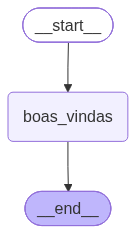

In [6]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 2.4 Operação dentro de um nó

Um nó é uma função Python e pode conter qualquer cálculo. O exemplo abaixo troca a formatação de texto por uma operação sobre números, e devolve dois campos em vez de um: a média das notas e a mensagem construída a partir dela.

Fluxo:

```text
START → calcular_media_aluno → END
```

{'nome': 'Julio', 'notas': [9, 8, 10], 'media': 9.0, 'mensagem': 'Olá, Julio! Sua média foi: 9.00.'}


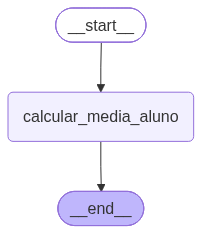

In [7]:
class EstadoDesempenhoAluno(TypedDict):
    nome: str
    notas: list[float]
    media: float
    mensagem: str


def calcular_media_aluno(state: EstadoDesempenhoAluno) -> dict:
    """Calcula a média e devolve apenas os campos novos."""
    notas = state["notas"]
    media = sum(notas) / len(notas)

    return {
        "media": media,
        "mensagem": f"Olá, {state['nome']}! Sua média foi: {media:.2f}."
    }


builder = StateGraph(EstadoDesempenhoAluno)

builder.add_node("calcular_media_aluno", calcular_media_aluno)

builder.add_edge(START, "calcular_media_aluno")
builder.add_edge("calcular_media_aluno", END)

graph = builder.compile()

resultado = graph.invoke({
    "nome": "Julio",
    "notas": [9, 8, 10]
})

print(resultado)
display_graph(graph)

## 2.5 Atualização parcial do estado

O nó devolveu `media` e `mensagem` em um único dicionário, e não repetiu `nome` nem `notas`. Uma alternativa seria alterar o dicionário `state` e devolvê-lo inteiro, o que produziria o mesmo resultado neste exemplo. O formato adotado é o retorno com os campos alterados:

```python
return {
    "campo_novo": valor,
    "outro_campo": outro_valor
}
```

Esse formato registra no próprio retorno quais campos o nó escreve. Ele também é a forma exigida quando um campo tem reducer, tratada na seção 5: o reducer combina o valor antigo do campo com a atualização devolvida, e um retorno com o estado inteiro entrega o valor antigo na posição da atualização, o que duplica o conteúdo do campo.

---

# 3. Sequência de nós

Um grafo com vários nós distribui o cálculo em etapas encadeadas. Esta seção divide o boletim do aluno em três operações: médias de cada etapa, média geral e relatório final. Cada nó lê campos escritos pelos anteriores.

Fluxo:

```text
START
  ↓
calcular_medias_por_etapa
  ↓
calcular_media_final
  ↓
gerar_relatorio_de_notas
  ↓
END
```

{'nome': 'Julio', 'notas1': [7, 8, 9], 'notas2': [10, 8, 7.5], 'media1': 8.0, 'media2': 8.5, 'media_geral': 8.25, 'mensagem': 'Olá, Julio! Suas médias foram 8.00 e 8.50. Sua média geral foi 8.25.'}


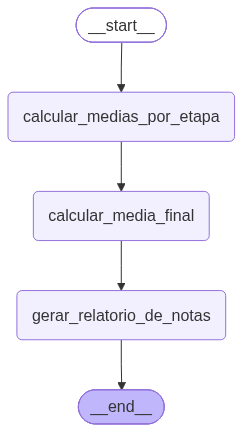

In [8]:
class EstadoNotasAluno(TypedDict):
    nome: str
    notas1: list[float]
    notas2: list[float]

    media1: float
    media2: float
    media_geral: float

    mensagem: str


def calcular_medias_por_etapa(state: EstadoNotasAluno) -> dict:
    """Calcula a média de cada uma das duas etapas."""
    media1 = sum(state["notas1"]) / len(state["notas1"])
    media2 = sum(state["notas2"]) / len(state["notas2"])

    return {
        "media1": media1,
        "media2": media2
    }


def calcular_media_final(state: EstadoNotasAluno) -> dict:
    """Combina as médias das etapas em uma média geral."""
    media_geral = (state["media1"] + state["media2"]) / 2

    return {
        "media_geral": media_geral
    }


def gerar_relatorio_de_notas(state: EstadoNotasAluno) -> dict:
    """Formata o relatório com as três médias."""
    mensagem = (
        f"Olá, {state['nome']}! "
        f"Suas médias foram {state['media1']:.2f} e {state['media2']:.2f}. "
        f"Sua média geral foi {state['media_geral']:.2f}."
    )

    return {
        "mensagem": mensagem
    }


builder = StateGraph(EstadoNotasAluno)

builder.add_node("calcular_medias_por_etapa", calcular_medias_por_etapa)
builder.add_node("calcular_media_final", calcular_media_final)
builder.add_node("gerar_relatorio_de_notas", gerar_relatorio_de_notas)

builder.add_edge(START, "calcular_medias_por_etapa")
builder.add_edge("calcular_medias_por_etapa", "calcular_media_final")
builder.add_edge("calcular_media_final", "gerar_relatorio_de_notas")
builder.add_edge("gerar_relatorio_de_notas", END)

graph = builder.compile()

resultado = graph.invoke({
    "nome": "Julio",
    "notas1": [7, 8, 9],
    "notas2": [10, 8, 7.5]
})

print(resultado)
display_graph(graph)

## 3.1 Separação em nós

As três operações caberiam em uma única função, com o mesmo resultado impresso. A divisão em nós muda o que a estrutura do programa expressa: o desenho do grafo mostra a ordem das etapas e os campos que cada uma escreve. Uma etapa nova entra como um `add_node` e duas chamadas de `add_edge`, sem alteração das funções existentes.

A separação também é a condição para as construções das seções seguintes. Uma aresta condicional escolhe entre nós, dois ramos paralelos partem de um nó comum, e um ciclo devolve o fluxo a um nó anterior; os três casos operam sobre a fronteira entre etapas.

## 3.2 Observação da sequência

O método `stream` devolve um evento por nó executado, no formato `{"nome_do_no": atualizacao}`. Com `stream_mode="updates"`, cada evento contém apenas os campos que aquele nó devolveu.

In [9]:
entrada = {
    "nome": "Julio",
    "notas1": [7, 8, 9],
    "notas2": [10, 8, 7.5]
}

for evento in graph.stream(entrada, stream_mode="updates"):
    print(evento)
    print("-" * 60)

{'calcular_medias_por_etapa': {'media1': 8.0, 'media2': 8.5}}
------------------------------------------------------------
{'calcular_media_final': {'media_geral': 8.25}}
------------------------------------------------------------
{'gerar_relatorio_de_notas': {'mensagem': 'Olá, Julio! Suas médias foram 8.00 e 8.50. Sua média geral foi 8.25.'}}
------------------------------------------------------------


## 3.3 Modos de stream

O argumento `stream_mode` determina o que cada evento carrega. Com `"updates"`, o evento traz a atualização devolvida pelo nó. Com `"values"`, o evento traz o estado inteiro depois daquele passo, e o nome do nó não aparece.

A comparação entre os dois modos torna visível a diferença entre atualização e estado. Na saída abaixo, os campos `media1` e `media2` aparecem a partir do segundo evento e permanecem até o final, enquanto no modo `updates` eles apareceram uma única vez.

In [10]:
for evento in graph.stream(entrada, stream_mode="values"):
    print(sorted(evento.keys()))

['nome', 'notas1', 'notas2']
['media1', 'media2', 'nome', 'notas1', 'notas2']
['media1', 'media2', 'media_geral', 'nome', 'notas1', 'notas2']
['media1', 'media2', 'media_geral', 'mensagem', 'nome', 'notas1', 'notas2']


---

# 4. Roteamento condicional

Os grafos anteriores executam os mesmos nós na mesma ordem. Uma aresta condicional escolhe o próximo nó a partir do estado corrente. A escolha fica em uma função separada, que devolve o nome de uma rota, e `add_conditional_edges` associa cada rota a um nó.

Neste exemplo, o nó `normalizar_operacao` ajusta o campo `operacao` para minúsculas e sem espaços nas bordas. A aresta condicional sai desse nó e direciona o fluxo para o cálculo correspondente:

```text
START
  ↓
normalizar_operacao
  ├── media
  ├── soma
  ├── maior_nota
  └── operacao_invalida
  ↓
END
```

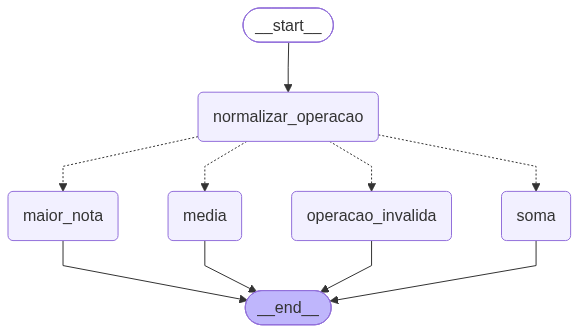

In [11]:
class EstadoOperacaoAluno(TypedDict):
    nome: str
    notas: list[float]
    operacao: str
    mensagem: str


def normalizar_operacao(state: EstadoOperacaoAluno) -> dict:
    """Uniformiza o campo lido pela função de rota."""
    return {"operacao": state["operacao"].strip().lower()}


def router(state: EstadoOperacaoAluno) -> Literal[
    "media",
    "soma",
    "maior_nota",
    "operacao_invalida"
]:
    """Devolve o nome da rota correspondente ao campo operacao."""
    operacao = state["operacao"]

    if operacao == "media":
        return "media"

    if operacao == "soma":
        return "soma"

    if operacao == "maior_nota":
        return "maior_nota"

    return "operacao_invalida"


def calcular_media(state: EstadoOperacaoAluno) -> dict:
    media = sum(state["notas"]) / len(state["notas"])

    return {
        "mensagem": f"Olá, {state['nome']}! Sua média foi {media:.2f}."
    }


def calcular_soma(state: EstadoOperacaoAluno) -> dict:
    soma = sum(state["notas"])

    return {
        "mensagem": f"Olá, {state['nome']}! A soma das suas notas é {soma:.2f}."
    }


def encontrar_maior_nota(state: EstadoOperacaoAluno) -> dict:
    maior_nota = max(state["notas"])

    return {
        "mensagem": f"Olá, {state['nome']}! Sua maior nota foi {maior_nota:.2f}."
    }


def informar_operacao_invalida(state: EstadoOperacaoAluno) -> dict:
    return {
        "mensagem": (
            f"Olá, {state['nome']}! Operação inválida. "
            "Use 'media', 'soma' ou 'maior_nota'."
        )
    }


builder = StateGraph(EstadoOperacaoAluno)

builder.add_node("normalizar_operacao", normalizar_operacao)
builder.add_node("media", calcular_media)
builder.add_node("soma", calcular_soma)
builder.add_node("maior_nota", encontrar_maior_nota)
builder.add_node("operacao_invalida", informar_operacao_invalida)

builder.add_edge(START, "normalizar_operacao")

builder.add_conditional_edges(
    "normalizar_operacao",
    router,
    {
        "media": "media",
        "soma": "soma",
        "maior_nota": "maior_nota",
        "operacao_invalida": "operacao_invalida",
    }
)

builder.add_edge("media", END)
builder.add_edge("soma", END)
builder.add_edge("maior_nota", END)
builder.add_edge("operacao_invalida", END)

graph = builder.compile()

display_graph(graph)

## 4.1 Leitura da execução

A aresta condicional tem três partes. A primeira é o nó de origem, `normalizar_operacao`, depois do qual a decisão é tomada. A segunda é a função `router`, chamada com o estado resultante desse nó, que devolve uma das quatro strings declaradas no `Literal`. A terceira é o mapa de rotas, que associa cada string ao nome de um nó registrado.

A função de rota fica fora do nó porque o LangGraph precisa da decisão como valor de retorno, e não como efeito no estado. Um `if` dentro de `normalizar_operacao` escolheria o cálculo, mas o grafo teria um nó só e o desenho não mostraria os caminhos possíveis. No desenho gerado, as arestas condicionais aparecem tracejadas; em uma execução, apenas um desses quatro caminhos é percorrido.

## 4.2 Rotas alternativas

O grafo compilado é o mesmo em todas as chamadas abaixo. O caminho percorrido muda conforme o valor de `operacao`. A terceira entrada usa `"  MAIOR_NOTA "`, que só corresponde a uma rota depois da normalização, e a quarta usa `multiplicar`, que não tem rota própria e cai em `operacao_invalida`.

In [12]:
entradas = [
    {"nome": "Julio", "notas": [9, 8, 10], "operacao": "media"},
    {"nome": "Julio", "notas": [9, 8, 10], "operacao": "soma"},
    {"nome": "Julio", "notas": [9, 8, 10], "operacao": "  MAIOR_NOTA "},
    {"nome": "Julio", "notas": [9, 8, 10], "operacao": "multiplicar"},
]

for entrada in entradas:
    resultado = graph.invoke(entrada)
    print(f"Operação recebida: {entrada['operacao']!r}")
    print(resultado["mensagem"])
    print("-" * 60)

Operação recebida: 'media'
Olá, Julio! Sua média foi 9.00.
------------------------------------------------------------
Operação recebida: 'soma'
Olá, Julio! A soma das suas notas é 27.00.
------------------------------------------------------------
Operação recebida: '  MAIOR_NOTA '
Olá, Julio! Sua maior nota foi 10.00.
------------------------------------------------------------
Operação recebida: 'multiplicar'
Olá, Julio! Operação inválida. Use 'media', 'soma' ou 'maior_nota'.
------------------------------------------------------------


## 4.3 Observação da rota

A saída de `invoke` mostra a mensagem final, sem indicar qual nó a produziu. Com `stream`, o nome do nó aparece como chave de cada evento. A execução abaixo emite dois eventos: um para `normalizar_operacao` e um para o nó escolhido pela rota.

In [13]:
entrada = {
    "nome": "Julio",
    "notas": [9, 8, 10],
    "operacao": "maior_nota"
}

for evento in graph.stream(entrada, stream_mode="updates"):
    print(evento)

{'normalizar_operacao': {'operacao': 'maior_nota'}}
{'maior_nota': {'mensagem': 'Olá, Julio! Sua maior nota foi 10.00.'}}


## 4.4 Ponto de entrada condicional

A aresta condicional deste exemplo sai de um nó que faz trabalho. Quando a decisão depende apenas da entrada, e nenhum processamento precede a escolha, `START` também aceita uma aresta condicional:

```python
builder.add_conditional_edges(START, router, {"media": "media", "soma": "soma"})
```

Nessa forma, o grafo não tem nó de origem para a decisão, e a primeira etapa executada já é a rota escolhida. O mapa de rotas é opcional nas duas formas: sem ele, o valor devolvido pela função de rota é usado como nome do nó de destino.

---

# 5. Acúmulo com reducers

Nos exemplos anteriores, a atualização devolvida por um nó substitui o valor anterior do campo. O retorno `{"mensagem": "nova mensagem"}` descarta a mensagem que estava no estado. Esse é o comportamento padrão de qualquer campo declarado sem anotação adicional.

Alguns campos precisam da regra oposta. Um histórico de execução, uma lista de documentos recuperados ou uma conversa acumulam as contribuições de vários nós:

```text
["recebeu entrada", "calculou média", "gerou relatório"]
```

Um **reducer** é a função que combina o valor antigo com a atualização. Ele é associado ao campo pela anotação `Annotated[tipo, funcao]`, e o LangGraph o aplica a cada retorno de nó que contenha aquele campo.

## 5.1 Histórico de execução

O estado abaixo declara `historico: Annotated[list[str], add]`. Com `operator.add` como reducer, o retorno `{"historico": ["nova etapa"]}` concatena a lista devolvida à lista existente. Cada um dos três nós registra uma linha, e o campo chega ao final com três entradas. Os demais campos do estado não têm anotação e seguem a regra de substituição.

Olá, Julio! Sua média foi 7.17 e sua situação é: aprovado.
['Média calculada: 7.17', 'Situação classificada como: aprovado', 'Mensagem final gerada']


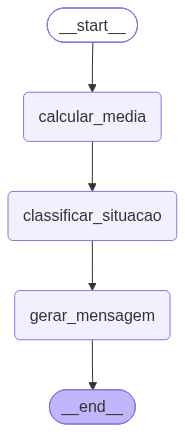

In [14]:
class EstadoComHistorico(TypedDict):
    nome: str
    notas: list[float]
    media: float
    situacao: str
    mensagem: str

    # Este campo será acumulado com operator.add.
    historico: Annotated[list[str], add]


def calcular_media_com_historico(state: EstadoComHistorico) -> dict:
    """Calcula a média e registra a etapa no histórico."""
    media = sum(state["notas"]) / len(state["notas"])

    return {
        "media": media,
        "historico": [f"Média calculada: {media:.2f}"]
    }


def classificar_situacao(state: EstadoComHistorico) -> dict:
    """Classifica a situação do aluno a partir da média."""
    media = state["media"]

    if media >= 7:
        situacao = "aprovado"
    else:
        situacao = "em recuperação"

    return {
        "situacao": situacao,
        "historico": [f"Situação classificada como: {situacao}"]
    }


def gerar_mensagem_com_historico(state: EstadoComHistorico) -> dict:
    """Formata a mensagem final com média e situação."""
    mensagem = (
        f"Olá, {state['nome']}! "
        f"Sua média foi {state['media']:.2f} e sua situação é: {state['situacao']}."
    )

    return {
        "mensagem": mensagem,
        "historico": ["Mensagem final gerada"]
    }


builder = StateGraph(EstadoComHistorico)

builder.add_node("calcular_media", calcular_media_com_historico)
builder.add_node("classificar_situacao", classificar_situacao)
builder.add_node("gerar_mensagem", gerar_mensagem_com_historico)

builder.add_edge(START, "calcular_media")
builder.add_edge("calcular_media", "classificar_situacao")
builder.add_edge("classificar_situacao", "gerar_mensagem")
builder.add_edge("gerar_mensagem", END)

graph = builder.compile()

resultado = graph.invoke({
    "nome": "Julio",
    "notas": [6.5, 7.0, 8.0]
})

print(resultado["mensagem"])
print(resultado["historico"])
display_graph(graph)

## 5.2 Função dos reducers

O campo `historico` terminou com as três linhas escritas pelos nós, na ordem de execução. O campo `mensagem` terminou apenas com o texto escrito pelo último nó. A diferença entre os dois está na anotação do estado, e não no código dos nós: os três retornos têm a mesma forma.

A entrada da execução não menciona `historico`. A anotação define também o valor inicial do campo: com `operator.add` sobre listas, o campo começa em `[]`, e o primeiro nó a escrever nele concatena com essa lista vazia. Um nó que leia `historico` antes de qualquer escrita recebe `[]`.

Campos sem reducer não têm valor inicial, e ler um campo ausente do estado levanta `KeyError`. Essa é a razão de a seção 7 ler o contador de tentativas com `state.get("tentativas", 0)`, em vez de acesso direto por colchetes.

Neste grafo o reducer é uma conveniência: os nós rodam em sequência e poderiam montar a lista lendo o valor anterior. A seção 6 apresenta o caso em que o reducer deixa de ser opcional.

---

# 6. Execução paralela

Um nó pode ter mais de uma aresta de saída para nós distintos. Nesse caso, o LangGraph executa os dois ramos no mesmo passo, chamado **superstep**, e só avança quando ambos terminam.

O exemplo calcula as médias das duas etapas em ramos paralelos e reúne os resultados em `consolidar_boletim`. O nó de reunião é o **fan-in**: ele tem duas arestas de entrada e roda uma única vez, depois dos dois ramos.

```text
START
  ↓
registrar_aluno
  ├──→ calcular_media_etapa1 ──┐
  └──→ calcular_media_etapa2 ──┤
                               ↓
                      consolidar_boletim
                               ↓
                              END
```

Olá, Julio! Sua média geral foi 8.25.
['Boletim de Julio recebido', 'Etapa 1 calculada: 8.00', 'Etapa 2 calculada: 8.50', 'Boletim consolidado: 8.25']


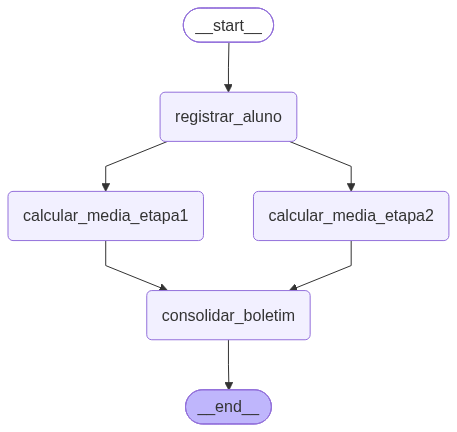

In [15]:
class EstadoBoletimParalelo(TypedDict):
    nome: str
    notas1: list[float]
    notas2: list[float]

    media1: float
    media2: float
    media_geral: float

    mensagem: str
    historico: Annotated[list[str], add]


def registrar_aluno(state: EstadoBoletimParalelo) -> dict:
    """Abre o histórico antes da abertura dos ramos."""
    return {"historico": [f"Boletim de {state['nome']} recebido"]}


def calcular_media_etapa1(state: EstadoBoletimParalelo) -> dict:
    """Primeiro ramo paralelo."""
    media1 = sum(state["notas1"]) / len(state["notas1"])

    return {
        "media1": media1,
        "historico": [f"Etapa 1 calculada: {media1:.2f}"]
    }


def calcular_media_etapa2(state: EstadoBoletimParalelo) -> dict:
    """Segundo ramo paralelo."""
    media2 = sum(state["notas2"]) / len(state["notas2"])

    return {
        "media2": media2,
        "historico": [f"Etapa 2 calculada: {media2:.2f}"]
    }


def consolidar_boletim(state: EstadoBoletimParalelo) -> dict:
    """Fan-in: lê os campos escritos pelos dois ramos."""
    media_geral = (state["media1"] + state["media2"]) / 2

    return {
        "media_geral": media_geral,
        "mensagem": f"Olá, {state['nome']}! Sua média geral foi {media_geral:.2f}.",
        "historico": [f"Boletim consolidado: {media_geral:.2f}"]
    }


builder = StateGraph(EstadoBoletimParalelo)

builder.add_node("registrar_aluno", registrar_aluno)
builder.add_node("calcular_media_etapa1", calcular_media_etapa1)
builder.add_node("calcular_media_etapa2", calcular_media_etapa2)
builder.add_node("consolidar_boletim", consolidar_boletim)

builder.add_edge(START, "registrar_aluno")
builder.add_edge("registrar_aluno", "calcular_media_etapa1")
builder.add_edge("registrar_aluno", "calcular_media_etapa2")
builder.add_edge("calcular_media_etapa1", "consolidar_boletim")
builder.add_edge("calcular_media_etapa2", "consolidar_boletim")
builder.add_edge("consolidar_boletim", END)

graph = builder.compile()

resultado = graph.invoke({
    "nome": "Julio",
    "notas1": [7, 8, 9],
    "notas2": [10, 8, 7.5]
})

print(resultado["mensagem"])
print(resultado["historico"])
display_graph(graph)

## 6.1 Leitura da execução

O grafo tem quatro nós e executa em três supersteps. O primeiro roda `registrar_aluno`. O segundo roda `calcular_media_etapa1` e `calcular_media_etapa2`, que partem do mesmo nó e não leem campos um do outro. O terceiro roda `consolidar_boletim`, que precisa de `media1` e `media2` e por isso espera os dois ramos.

O campo `historico` recebeu duas escritas no mesmo superstep, uma de cada ramo. O reducer `operator.add` combinou as duas listas. A ordem entre contribuições de um mesmo superstep não é determinada pelo grafo: quando a ordem importa, os ramos escrevem em campos separados, ou registram junto com o valor um dado que permita ordená-lo depois.

## 6.2 Supersteps na saída de stream

Com `stream_mode="values"`, cada evento é o estado ao final de um superstep. A saída tem quatro eventos: o estado inicial e o resultado de cada um dos três passos. O primeiro evento já contém `historico`, com o valor `[]` dado pelo reducer, embora a entrada não traga esse campo.

Os campos `media1` e `media2` aparecem juntos, no terceiro evento, embora tenham sido escritos por nós diferentes. Essa coincidência identifica o superstep. Em um encadeamento sequencial, dois nós distintos produziriam dois eventos.

In [16]:
entrada = {
    "nome": "Julio",
    "notas1": [7, 8, 9],
    "notas2": [10, 8, 7.5]
}

for evento in graph.stream(entrada, stream_mode="values"):
    print(sorted(evento.keys()))

['historico', 'nome', 'notas1', 'notas2']
['historico', 'nome', 'notas1', 'notas2']
['historico', 'media1', 'media2', 'nome', 'notas1', 'notas2']
['historico', 'media1', 'media2', 'media_geral', 'mensagem', 'nome', 'notas1', 'notas2']


## 6.3 Escrita concorrente sem reducer

Em um grafo sequencial, um campo sem reducer recebe uma escrita por passo, e a substituição resolve o valor. Em ramos paralelos, dois nós podem escrever no mesmo campo dentro do mesmo superstep, e o LangGraph não tem regra para escolher entre os dois valores.

O grafo abaixo repete a topologia da seção, com `historico` declarado sem anotação. Nenhum nó lê o estado, e por isso a entrada é um dicionário vazio. A chamada é envolvida em `try` porque o erro é o assunto desta subseção.

In [17]:
class EstadoSemReducer(TypedDict):
    historico: list[str]


def registrar_sem_reducer(state: EstadoSemReducer) -> dict:
    return {"historico": ["Boletim recebido"]}


def etapa1_sem_reducer(state: EstadoSemReducer) -> dict:
    return {"historico": ["Etapa 1 calculada"]}


def etapa2_sem_reducer(state: EstadoSemReducer) -> dict:
    return {"historico": ["Etapa 2 calculada"]}


builder = StateGraph(EstadoSemReducer)

builder.add_node("registrar", registrar_sem_reducer)
builder.add_node("etapa1", etapa1_sem_reducer)
builder.add_node("etapa2", etapa2_sem_reducer)

builder.add_edge(START, "registrar")
builder.add_edge("registrar", "etapa1")
builder.add_edge("registrar", "etapa2")
builder.add_edge("etapa1", END)
builder.add_edge("etapa2", END)

graph = builder.compile()

try:
    graph.invoke({})
except InvalidUpdateError as erro:
    print(erro)

At key 'historico': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


## 6.4 Discussão

A mensagem do erro nomeia a chave em conflito e indica a correção: anotar o campo. A anotação é necessária apenas onde há escrita concorrente. No grafo da seção, `media1` e `media2` são escritos por um nó cada e ficam sem anotação; `historico` recebe escrita dos dois ramos e leva `Annotated[list[str], add]`.

---

# 7. Ciclos controlados

Uma aresta pode apontar para um nó já executado, o que forma um ciclo. O fluxo repete a etapa e reavalia a condição de saída a cada volta. O número de execuções de um nó passa a depender do estado corrente.

O exemplo gera uma recomendação de estudo, avalia se ela atende a critérios de especificidade e repete a geração enquanto o critério não for atendido. A repetição para quando a avaliação aprova a recomendação ou quando o número de tentativas chega ao limite:

```text
START
  ↓
gerar_recomendacao
  ↓
avaliar_recomendacao
  ├── repetir → gerar_recomendacao
  └── finalizar → END
```

Julio, sua média em matemática foi 6.2. Revise os tópicos principais da disciplina, resolva exercícios práticos e separe 30 minutos por dia para corrigir os erros das questões anteriores.
2


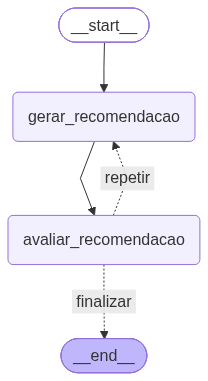

In [18]:
class EstadoRecomendacao(TypedDict):
    nome: str
    disciplina: str
    media: float

    tentativas: int
    recomendacao: str
    avaliacao: str

    historico: Annotated[list[str], add]


def gerar_recomendacao(state: EstadoRecomendacao) -> dict:
    """Produz uma recomendação, mais detalhada a partir da segunda tentativa."""
    # O campo tentativas não tem reducer e pode faltar na entrada.
    tentativa = state.get("tentativas", 0) + 1

    if tentativa == 1:
        recomendacao = "Estude mais."
    else:
        recomendacao = (
            f"{state['nome']}, sua média em {state['disciplina']} "
            f"foi {state['media']:.1f}. Revise os tópicos principais da "
            "disciplina, resolva exercícios práticos e separe 30 minutos "
            "por dia para corrigir os erros das questões anteriores."
        )

    return {
        "tentativas": tentativa,
        "recomendacao": recomendacao,
        "historico": [f"Tentativa {tentativa}: recomendação gerada"]
    }


def avaliar_recomendacao(state: EstadoRecomendacao) -> dict:
    """Verifica se a recomendação cita exercícios, tempo e tem 15 palavras."""
    recomendacao = state["recomendacao"]

    tem_exercicios = "exercícios" in recomendacao.lower()
    tem_tempo = "minutos" in recomendacao.lower() or "horas" in recomendacao.lower()
    eh_especifica = len(recomendacao.split()) >= 15

    if tem_exercicios and tem_tempo and eh_especifica:
        avaliacao = "boa"
    else:
        avaliacao = "precisa_melhorar"

    return {
        "avaliacao": avaliacao,
        "historico": [f"Avaliação da recomendação: {avaliacao}"]
    }


def decidir_proximo_passo(
    state: EstadoRecomendacao
) -> Literal["repetir", "finalizar"]:
    """Encerra na aprovação ou no limite de três tentativas."""
    if state["avaliacao"] == "boa":
        return "finalizar"

    if state["tentativas"] >= 3:
        return "finalizar"

    return "repetir"


builder = StateGraph(EstadoRecomendacao)

builder.add_node("gerar_recomendacao", gerar_recomendacao)
builder.add_node("avaliar_recomendacao", avaliar_recomendacao)

builder.add_edge(START, "gerar_recomendacao")
builder.add_edge("gerar_recomendacao", "avaliar_recomendacao")

builder.add_conditional_edges(
    "avaliar_recomendacao",
    decidir_proximo_passo,
    {
        "repetir": "gerar_recomendacao",
        "finalizar": END,
    }
)

graph = builder.compile()

resultado = graph.invoke({
    "nome": "Julio",
    "disciplina": "matemática",
    "media": 6.2
})

print(resultado["recomendacao"])
print(resultado["tentativas"])
display_graph(graph)

## 7.1 Leitura da execução

O campo `tentativas` terminou com valor 2. A primeira recomendação, `"Estude mais."`, falha nos três critérios de `avaliar_recomendacao`, e `decidir_proximo_passo` devolve `"repetir"`. A aresta condicional leva o fluxo de volta a `gerar_recomendacao`, que produz o texto detalhado. A segunda avaliação devolve `"boa"` e a rota `"finalizar"` liga o fluxo a `END`.

O campo `historico` registra as quatro passagens por nó, em ordem. No desenho do grafo, a aresta que sai de `avaliar_recomendacao` e retorna a `gerar_recomendacao` é o ciclo.

## 7.2 Observação do ciclo

Com `stream_mode="updates"`, cada volta do ciclo aparece como um par de eventos: a geração e a avaliação. A contagem de eventos indica quantas voltas o grafo executou.

In [19]:
entrada = {
    "nome": "Julio",
    "disciplina": "matemática",
    "media": 6.2
}

for evento in graph.stream(entrada, stream_mode="updates"):
    print(evento)
    print("-" * 60)

{'gerar_recomendacao': {'tentativas': 1, 'recomendacao': 'Estude mais.', 'historico': ['Tentativa 1: recomendação gerada']}}
------------------------------------------------------------
{'avaliar_recomendacao': {'avaliacao': 'precisa_melhorar', 'historico': ['Avaliação da recomendação: precisa_melhorar']}}
------------------------------------------------------------
{'gerar_recomendacao': {'tentativas': 2, 'recomendacao': 'Julio, sua média em matemática foi 6.2. Revise os tópicos principais da disciplina, resolva exercícios práticos e separe 30 minutos por dia para corrigir os erros das questões anteriores.', 'historico': ['Tentativa 2: recomendação gerada']}}
------------------------------------------------------------
{'avaliar_recomendacao': {'avaliacao': 'boa', 'historico': ['Avaliação da recomendação: boa']}}
------------------------------------------------------------


## 7.3 Critério de parada

Um ciclo precisa de uma condição que leve o fluxo a `END`. Neste exemplo, `decidir_proximo_passo` tem duas condições de saída: a avaliação igual a `"boa"` e o contador `tentativas` igual ou maior que 3. A segunda condição encerra a execução mesmo quando o critério de qualidade nunca é atendido.

O contador é mantido no próprio estado e incrementado dentro de `gerar_recomendacao`. Como `tentativas` não tem reducer, ele não recebe valor inicial e falta no estado da primeira passagem, o que faz o nó lê-lo com `state.get("tentativas", 0)`. Sem uma condição de parada, o grafo repetiria o ciclo até esbarrar no limite de passos do LangGraph, tratado na subseção seguinte.

## 7.4 Limite de passos do framework

O LangGraph interrompe uma execução que passa de um número de supersteps, configurável por `recursion_limit` no segundo argumento da chamada. Ao atingir o limite, a execução emite `GraphRecursionError`. O valor padrão varia entre versões do pacote e consta na documentação da versão instalada.

O grafo abaixo tem um ciclo sem condição de saída: o nó `contar_volta` incrementa um contador e devolve o fluxo a si mesmo. A chamada fixa o limite em 4 para que o erro apareça em poucas voltas. Nada é impresso além da mensagem do erro, porque a execução não chega a devolver estado.

In [20]:
class EstadoContador(TypedDict):
    voltas: int


def contar_volta(state: EstadoContador) -> dict:
    """Incrementa o contador e devolve o fluxo a si mesmo."""
    return {"voltas": state["voltas"] + 1}


builder = StateGraph(EstadoContador)

builder.add_node("contar_volta", contar_volta)

builder.add_edge(START, "contar_volta")
builder.add_edge("contar_volta", "contar_volta")

graph = builder.compile()

try:
    graph.invoke({"voltas": 0}, {"recursion_limit": 4})
except GraphRecursionError as erro:
    print(erro)

Recursion limit of 4 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT


## 7.5 Discussão

As duas formas de encerrar um ciclo têm origem e efeito diferentes:

| | Limite de passos | Critério de parada |
|---|---|---|
| Definido em | `recursion_limit`, na chamada | função de rota, no código do grafo |
| Alcance | qualquer grafo | o problema que o grafo modela |
| Ao ser atingido | levanta `GraphRecursionError` | leva o fluxo a `END` |
| A chamada devolve | nada | o estado completo |

Um grafo cujo ciclo só para no `recursion_limit` não produz resultado nas execuções que chegam ao limite: `invoke` levanta a exceção, e o estado acumulado até ali não é devolvido. O limite conta supersteps, e não execuções de nó, de modo que os ramos paralelos da seção 6 consomem uma unidade só.

---

# 8. Exercícios de fixação

Os exercícios abaixo partem dos grafos já construídos no notebook. Cada enunciado pede uma modificação pequena e uma verificação da modificação por execução: comparar saídas de entradas diferentes, observar os eventos com `stream` ou inspecionar o desenho com `display_graph`. O último exercício não usa código.

## Exercício 1 — Campo de curso

No grafo da seção 2, acrescente o campo `curso` ao estado e ao texto da mensagem, no formato abaixo. Execute o grafo com dois valores diferentes de `curso` e compare as duas saídas.

```text
Olá, Julio! Este é o curso de Agentes com LLMs.
```

## Exercício 2 — Rota de menor nota

No grafo da seção 4, acrescente a operação `menor_nota`, que devolve a menor nota da lista. A alteração envolve o `Literal` da função `router`, um nó novo, o mapa de rotas e a aresta até `END`. Chame `display_graph` antes e depois da alteração e compare o número de arestas tracejadas.

## Exercício 3 — Roteamento por faixa de média

Construa um grafo que calcule a média das notas em um nó e, em seguida, direcione o fluxo por aresta condicional para um de três nós: `aprovado` para média igual ou maior que 7, `recuperacao` para média entre 5 e 6.99, e `reprovado` para média menor que 5. Cada nó escreve uma mensagem própria. Execute com três listas de notas que ativem os três caminhos.

## Exercício 4 — Terceiro ramo paralelo

No grafo da seção 6, acrescente um ramo `contar_avaliacoes`, que parte de `registrar_aluno` e escreve em `historico` o total de notas das duas etapas. Execute com `stream_mode="values"` e confirme que o campo escrito pelo ramo novo aparece no mesmo evento que `media1` e `media2`.

## Exercício 5 — Ciclo com outro critério

No grafo da seção 7, altere o limite de tentativas de 3 para 5 e exija 35 palavras em `eh_especifica`. Execute com `stream` e conte quantas voltas o ciclo completa até parar. Identifique, pela saída, qual das duas condições de `decidir_proximo_passo` encerrou a execução.

## Exercício 6 — Análise sem execução

Sem rodar código, responda em texto:

1. Um grafo tem um campo `mensagens` sem reducer, escrito por três nós em sequência. Descreva o conteúdo desse campo ao final da execução e o que muda se o campo for anotado com `Annotated[list[str], add]`.
2. Esses mesmos três nós passam a partir de um nó comum, em paralelo. Indique o que a execução produz com e sem a anotação.
3. Explique por que a função de rota da seção 4 fica fora do nó de origem, em vez de ser um `if` dentro dele.

---

# 9. Resumo da aula

Este notebook apresentou os elementos do LangGraph a partir de grafos executáveis sem chamadas a LLM. A construção seguiu do menor grafo possível, com um nó, até grafos com aresta condicional, ramos paralelos, campo acumulativo e ciclo com critério de parada. Em todos os casos, o mesmo ciclo se repete: um nó lê o estado, executa uma tarefa e devolve os campos que alterou.

| Conceito | Ideia principal |
|---|---|
| Grafo | Estrutura que organiza o fluxo de execução |
| Estado | Dados compartilhados entre os nós, declarados em `TypedDict` |
| Nó | Função que executa uma etapa e devolve um dicionário |
| Atualização parcial | Retorno contendo apenas os campos alterados |
| Aresta | Conexão que define o próximo passo do fluxo |
| Roteamento condicional | Escolha do próximo nó por uma função que devolve o nome da rota |
| Reducer | Função que combina o valor antigo do campo com a atualização |
| Superstep | Passo de execução que roda em paralelo os nós sem dependência entre si |
| Fan-in | Nó com várias arestas de entrada, executado depois de todos os ramos |
| Ciclo | Aresta que devolve o fluxo a um nó já executado |
| Critério de parada | Condição que leva o ciclo a `END` |
| `recursion_limit` | Limite de supersteps do framework, com erro em vez de resultado |
| `stream` | Emissão de eventos por passo, com a atualização ou o estado |

Os grafos deste notebook contêm apenas funções Python. Os mesmos elementos descrevem grafos em que um nó chama um LLM: o estado passa a guardar mensagens, e a função de rota passa a ler a saída do modelo.

## 9.1 Checklist de compreensão

Questões de verificação:

1. Quais campos compõem o estado de um grafo e onde eles são declarados?
2. O que um nó recebe como argumento e o que devolve?
3. Qual é a diferença entre `add_edge` e `add_conditional_edges`, e o que o mapa de rotas associa?
4. Em que situação um campo do estado precisa de reducer, e em qual delas a ausência do reducer produz erro?
5. O que define os nós que rodam em um mesmo superstep?
6. Por que a ordem das contribuições de ramos paralelos ao mesmo campo não é determinada pelo grafo?
7. O que encerra um ciclo, e qual é a diferença entre o critério de parada e o `recursion_limit`?
8. Qual informação `stream_mode="updates"` mostra que `stream_mode="values"` não mostra?

## 9.2 Próximos passos

Temas que dão continuidade ao assunto:

- estado baseado em mensagens, com o reducer `add_messages`;
- nós que chamam um LLM com prompt de sistema;
- uso do modelo como classificador de intenção, com a saída alimentando a função de rota;
- saída estruturada com `BaseModel` do Pydantic no lugar de `TypedDict`;
- tool calling, o mecanismo pelo qual um modelo pede a chamada de uma função;
- `Command` como retorno de nó, que reúne atualização de estado e destino do fluxo;
- `Send` para abrir um número de ramos paralelos definido em tempo de execução;
- `retry_policy` para repetir nós que levantam exceção;
- persistência do estado entre execuções com checkpointers.

# 10. Referências

- Documentação oficial do LangGraph: https://docs.langchain.com/oss/python/langgraph/overview
- LangGraph — Graph API: https://docs.langchain.com/oss/python/langgraph/graph-api
- LangGraph — Uso da Graph API: https://docs.langchain.com/oss/python/langgraph/use-graph-api
- LangGraph — Streaming: https://docs.langchain.com/oss/python/langgraph/streaming
- Referência da API do LangGraph: https://reference.langchain.com/python/langgraph/
- Repositório oficial do LangGraph: https://github.com/langchain-ai/langgraph